<a href="https://colab.research.google.com/github/NguyenThai365/pka-google-colab-notebook/blob/main/%5BDeepLearning%5D%2023010531%20Constrastive%20learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NSGA gốc**

# **NSGA-II**

* Non-dominated Sorting + Crowding-Distance Assignment:
https://pymoo.org/algorithms/moo/nsga2.html?highlight=nsga%20ii




In [ ]:
!pip install pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.5/309.5 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.8/786.8 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.9 MB/s eta 0:00:00


Thuật toán NSGA-II (Nondominated Sorting Genetic Algorithm II) để giải bài toán tối ưu đa mục tiêu chuẩn `ZDT1` bằng thư viện `pymoo`

#### Hàm mục tiêu của `ZDT1`

Minimize:
$$
f_1(x) = x_1
$$

$$
f_2(x) = g(x)\left(1 - \sqrt{\frac{x_1}{g(x)}}\right)
$$

với:
$$
g(x) = 1 + 9 \cdot \frac{\sum_{i=2}^{n} x_i}{n - 1}
$$

Miền nghiệm:
$$
0 \leq x_i \leq 1
$$

Pareto front là đường cong mượt:
$$
f_1 \in [0,1] \quad \text{và} \quad f_2 = 1 - \sqrt{f_1}
$$



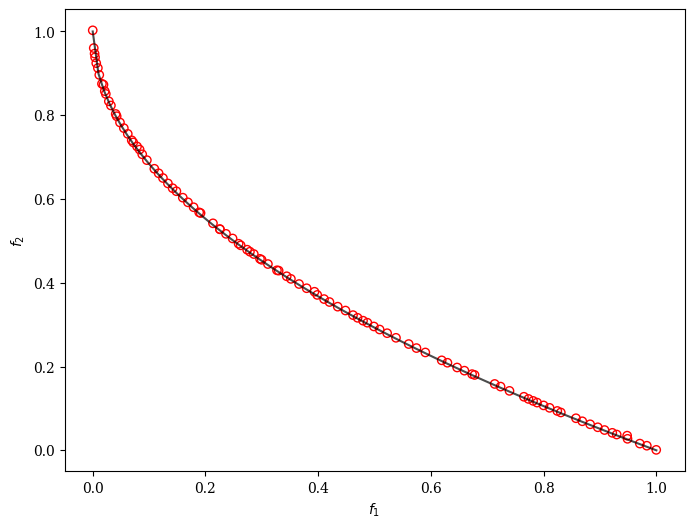

In [ ]:
from pymoo.algorithms.moo.nsga2 import NSGA2 #lớp cài đặt thuật toán NSGA-II.
from pymoo.problems import get_problem #dùng để tải sẵn các bài toán benchmark (ví dụ ZDT, DTLZ,...).
from pymoo.optimize import minimize #hàm thực thi quá trình tối ưu hóa.
from pymoo.visualization.scatter import Scatter #công cụ vẽ đồ thị Pareto Front (hiển thị kết quả đa mục tiêu).

problem = get_problem("zdt1")

algorithm = NSGA2(pop_size=100)

res = minimize(problem,
               algorithm,
               ('n_gen', 200),
               seed=1,
               verbose=False)

plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.show()

Thuật toán NSGA-II (Nondominated Sorting Genetic Algorithm II) để giải bài toán tối ưu đa mục tiêu chuẩn `ZDT5` bằng thư viện `pymoo`

#### Hàm mục tiêu của `ZDT5`

Bài toán **ZDT5** là bài toán tối ưu đa mục tiêu **nhị phân** (biến chỉ nhận giá trị 0 hoặc 1).


#### Mô tả biến

Biến quyết định được mã hoá nhị phân:  
$ x = (x_1, x_2, \dots, x_m) $

Trong đó:  
- $ x_1 $ gồm **30 bit**,  
- Mỗi $ x_i $ (với $ i = 2, \dots, m $) gồm **5 bit**.

Ký hiệu:
$$
u(x_i) = \sum_{j=1}^{l_i} x_{ij}
$$
với $ l_1 = 30 $ và $ l_i = 5 $ cho $ i = 2, \dots, m $.


#### Hàm mục tiêu

Minimize:
$$
f_1(x) = 1 + u(x_1)
$$
$$
f_2(x) = g(x) \cdot h(f_1, g)
$$

trong đó:
$$
g(x) = \sum_{i=2}^{m} g_i(x_i)
$$

$$
g_i(x_i) =
\begin{cases}
2 + u(x_i), & \text{nếu } u(x_i) < 5, \\
1, & \text{nếu } u(x_i) = 5
\end{cases}
$$

và:
$$
h(f_1, g) = \frac{1}{f_1}
$$

#### Miền nghiệm:
Tất cả các biến
$$
x_{ij} \in \{0, 1\} .
$$

#### Pareto front
Pareto front của ZDT5 không liên tục (*discontinuous*) và gồm các điểm rời rạc, tương ứng với:
$$
f_1 \in \{1, 2, 3, \dots, 31\}, \quad f_2 = \frac{1}{f_1}
$$

Do đó, đường cong Pareto front là **tập hợp 31 điểm rời rạc**.


In [ ]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.problems import get_problem
from pymoo.operators.crossover.pntx import TwoPointCrossover
from pymoo.operators.mutation.bitflip import BitflipMutation
from pymoo.operators.sampling.rnd import BinaryRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

problem = get_problem("zdt5")

algorithm = NSGA2(pop_size=100,
                  sampling=BinaryRandomSampling(),
                  crossover=TwoPointCrossover(),
                  mutationMutation(),
                  eliminate_duplican=Bitflites=True)

res = minimize(problem,
               algorithm,
               ('n_gen', 500),
               seed=1,
               verbose=False)

Scatter().add(res.F).show()

SyntaxError: positional argument follows keyword argument (ipython-input-3366582472.py, line 15)

Bước đầu tiên quan trọng trong NSGA-II: nó sắp xếp tất cả các cá thể trong quần thể theo cấp không bị trội (non-domination rank).

**Nondominated sorting (fast-non-dominated-sort)** được gọi gián tiếp từ module `pymoo.util.nds.non_dominated_sorting` bên trong lớp `NSGA2`.

Khi tạo và chạy:
```
from pymoo.algorithms.moo.nsga2 import NSGA2
algorithm = NSGA2(pop_size=100)
```
Bên trong file `nsga2.py` (trong `pymoo/algorithms/moo/nsga2.py`), NSGA-II được cài đặt như sau:
```
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from pymoo.util.crowding_distance import calc_crowding_distance
```

In [ ]:
# Trong pymoo

import numpy as np

def dominates(p, q):
    """Trả về True nếu cá thể p trội hơn q."""
    return np.all(p <= q) and np.any(p < q)

def fast_non_dominated_sort(F_values):
    """
    F_values: ma trận (N x M) – N cá thể, M mục tiêu
    Trả về: danh sách các front [F1, F2, F3, ...]
    """
    N = len(F_values)
    S = [[] for _ in range(N)]
    n = np.zeros(N, dtype=int)
    rank = np.zeros(N, dtype=int)
    fronts = [[]]

    # So sánh từng cặp cá thể (p, q)
    for p in range(N):
        for q in range(N):
            if dominates(F_values[p], F_values[q]):
                S[p].append(q)
            elif dominates(F_values[q], F_values[p]):
                n[p] += 1
        if n[p] == 0:
            rank[p] = 1
            fronts[0].append(p)

    # Tạo các front tiếp theo
    i = 0
    while len(fronts[i]) > 0:
        Q = []
        for p in fronts[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0:
                    rank[q] = i + 2
                    Q.append(q)
        i += 1
        fronts.append(Q)

    # Loại bỏ front rỗng cuối cùng
    fronts.pop()

    return fronts, rank


In [ ]:
# Test the fast_non_dominated_sort function
F_test = np.array([
    [2, 4],
    [3, 3],
    [4, 2],
    [1, 5],
    [5, 1],
    [2.5, 4.5],
    [3.5, 3.5],
    [6, 3],
    [4, 4]
])

fronts_test, rank_test = fast_non_dominated_sort(F_test)

print("Test Objective Values:\n", F_test)
print("\nFronts (indices):", fronts_test)
print("Ranks:", rank_test)

# # Verify the ranks by checking dominance within and between fronts
# print("\nVerification:")
# for i, front in enumerate(fronts_test):
#     print(f"  Front {i+1}: {front}")
#     for p_idx in front:
#         for q_idx in front:
#             if p_idx != q_idx:
#                 # Within the same front, no individual should dominate another
#                 if dominates(F_test[p_idx], F_test[q_idx]):
#                     print(f"    Error: Individual {p_idx} dominates {q_idx} in the same front {i+1}")
#         if i > 0:
#             # Individuals in a lower front should dominate individuals in a higher front
#             for lower_front_idx in fronts_test[i-1]:
#                  if not dominates(F_test[lower_front_idx], F_test[p_idx]):
#                      print(f"    Warning: Individual {lower_front_idx} from Front {i} does not dominate {p_idx} from Front {i+1}")

Bước thứ hai quan trọng trong NSGA-II (sau khi đã phân loại theo cấp không bị trội), giúp đo lường độ “đông đúc” (crowdedness) giữa các nghiệm trên cùng một front nhằm duy trì đa dạng quần thể.

**Crowding-distance-assignment** được gọi gián tiếp từ file `pymoo.algorithms.moo.nsga2`.

In [ ]:
# Trong pymoo
import numpy as np

def calc_crowding_distance(F):
    n_points, n_obj = F.shape
    distance = np.zeros(n_points)
    # Nếu chỉ có 1 hoặc 2 điểm -> distance = inf
    if n_points <= 2:
        distance[:] = np.inf
        return distance

    # Lặp qua từng mục tiêu
    for m in range(n_obj):
        sorted_idx = np.argsort(F[:, m])
        f_min, f_max = F[sorted_idx[0], m], F[sorted_idx[-1], m]
        distance[sorted_idx[0]] = distance[sorted_idx[-1]] = np.inf

        for i in range(1, n_points - 1):
            distance[sorted_idx[i]] += (F[sorted_idx[i + 1], m] - F[sorted_idx[i - 1], m]) / (f_max - f_min)

    return distance


Crowded-Comparison Operator - quy tắc so sánh 2 vật thể

Định nghĩa toán học của `crowded-comparison operator (≺ₙ)`
$ i \prec_n j \text{ if } (rank_i < rank_j) \text{ or } (rank_i = rank_j \text{ and } distance_i > distance_j) $


In [ ]:
def crowded_comparison_operator(rank_i, rank_j, distance_i, distance_j):
    if rank_i < rank_j:
        return True      # i trội hơn j
    elif rank_i == rank_j and distance_i > distance_j:
        return True      # i trội hơn j nếu có khoảng cách lớn hơn
    else:
        return False     # j trội hơn i

Phần lõi (`main loop`) của thuật toán, nơi các bước elitism, non-dominated sorting, crowding-distance assignment và chọn lọc thế hệ mới diễn ra

In [ ]:
# Trong mã giả
R_t = P_t ∪ Q_t
F = fast-non-dominated-sort(R_t)
until |P_{t+1}| + |F_i| ≤ N
    crowding-distance-assignment(F_i)
    P_{t+1} = P_{t+1} ∪ F_i
i = i + 1
Sort(F_i, ≺_n)
P_{t+1} = P_{t+1} ∪ F_i[1:(N - |P_{t+1}|)]

In [ ]:
# Trong pymoo
def select_by_rank_and_distance(fronts, N):
    P_next = []
    for Fi in fronts:
        if len(P_next) + len(Fi) <= N:
            P_next.extend(Fi)
        else:
            distances = calc_crowding_distance(Fi)
            sorted_idx = np.argsort(-distances)
            remaining = N - len(P_next)
            P_next.extend(Fi[sorted_idx[:remaining]])
            break
    return P_next

In [ ]:
for t in range(n_gen):
    # 1. Tạo con từ quần thể hiện tại
    Q_t = algorithm.mating.do(problem, P_t)

    # 2. Kết hợp cha và con
    R_t = Population.merge(P_t, Q_t)

    # 3. Sắp xếp không bị trội
    F = NonDominatedSorting().do(R_t)

    # 4. Tính crowding distance cho từng front
    for Fi in F:
        calc_crowding_distance(Fi)

    # 5. Chọn N cá thể tốt nhất (elitism)
    P_{t+1} = select_by_rank_and_distance(F, N)

    # 6. Tạo thế hệ mới
    Q_{t+1} = algorithm.mating.do(problem, P_{t+1})


`minimize()` chính là bao bọc toàn bộ vòng lặp trên.

In [ ]:
res = minimize(problem,
               algorithm,
               ('n_gen', 200),  # hoặc 500 cho ZDT5
               seed=1,
               verbose=False)

**Giải thích chi tiết từng bước**

| **Bước** | **Tên bước**                                                 | **Mục tiêu / Giải thích**                                                                                 |
| -------- | ------------------------------------------------------------ | --------------------------------------------------------------------------------------------------------- |
|  **1** | **Khởi tạo quần thể (Initialization)**                       | Sinh ngẫu nhiên quần thể ban đầu ( P_0 ), mỗi cá thể là nghiệm ứng viên.                                  |
|  **2** | **Đánh giá quần thể (Evaluation)**                           | Tính giá trị các hàm mục tiêu ( f_1, f_2, ..., f_m ) cho từng cá thể.                                     |
|  **3** | **Tạo quần thể con (make-new-pop)**                          | Chọn cặp cha mẹ, lai ghép (crossover), đột biến (mutation) để tạo quần thể con ( Q_t ).                   |
|  **4** | **Kết hợp cha và con (Rt = Pt ∪ Qt)**                        | Hợp 2 quần thể lại để xét tất cả cá thể hiện có.                                                          |
|  **5** | **Phân loại không bị trội (fast-non-dominated-sort)**        | Chia quần thể ( R_t ) thành các *front* F₁, F₂, … dựa trên quan hệ trội (dominance).                      |
|  **6** | **Tính khoảng cách đông đúc (crowding-distance-assignment)** | Tính khoảng cách cho từng cá thể trong mỗi *front* để đo độ đa dạng.                                      |
|  **7** | **So sánh ≺ₙ (Crowded-Comparison Operator)**                 | Dùng rank và distance để sắp xếp ưu tiên: rank thấp hơn → tốt hơn, nếu bằng → distance lớn hơn → tốt hơn. |
|  **8** | **Chọn lọc quần thể mới (elitism)**                          | Giữ lại N cá thể tốt nhất (từ các front đầu tiên).                                                        |
|  **9** | **Lặp lại (loop)**                                           | Lặp lại các bước từ 3 → 8 cho tới khi đạt số thế hệ hoặc điều kiện dừng.                                  |


**Đối chiếu mã giả với mã thật trong thư viện** `pymoo`

| **Bước** | **Mã giả Deb (2002)**              | **Thực hiện trong `pymoo`**                                    | **Ghi chú**                   |
| -------- | ---------------------------------- | -------------------------------------------------------------- | ----------------------------- |
| 1      | `Initialize P0`                    | `BinaryRandomSampling()`, `FloatRandomSampling()`              | Sinh quần thể ban đầu         |
| 2      | `Evaluate(P0)`                     | `problem.evaluate(P)`                                          | Tính giá trị các hàm mục tiêu |
| 3      | `Qt = make-new-pop(Pt)`            | `algorithm.mating.do(problem, P_t)`                            | Lai ghép + đột biến           |
| 4      | `Rt = Pt ∪ Qt`                     | `R = Population.merge(P, Q)`                                   | Hợp cha & con                 |
| 5      | `fast-non-dominated-sort(Rt)`      | `NonDominatedSorting().do(R.F)`                                | Xác định rank (F₁, F₂, ...)   |
| 6      | `crowding-distance-assignment(Fi)` | `calc_crowding_distance(R[Fi].F)`                              | Tính khoảng cách từng front   |
| 7      | `Sort(Fi, ≺n)`                     | Logic so sánh `rank_i < rank_j` hoặc `distance_i > distance_j` | So sánh theo ≺ₙ               |
| 8      | `Pt+1 = ...`                       | `select_by_rank_and_distance(R, F, N)`                         | Giữ lại N cá thể tốt nhất     |
| 9      | `t = t + 1`                        | vòng lặp `for gen in range(n_gen)`                             | Lặp lại tiến hóa              |


**3 bước quan trọng của NSGA-II**

| Thứ tự   | Bước                                   | Vai trò chính                                         | Mục tiêu của bước                                  |
| -------- | -------------------------------------- | ----------------------------------------------------- | -------------------------------------------------- |
|  **1** | **Fast Non-Dominated Sort (FND Sort)** | Phân loại nghiệm theo *cấp Pareto* (F₁, F₂, F₃, …)    | Đảm bảo **tính ưu tiên đa mục tiêu**               |
|  **2** | **Crowding Distance Assignment (CDA)** | Tính khoảng cách giữa các nghiệm trong cùng một front | Duy trì **đa dạng nghiệm** (tránh tụ tập một vùng) |
|  **3** | **Crowded Comparison Operator (≺ₙ)**   | So sánh 2 cá thể dựa vào rank và distance             | Quyết định **cá thể nào được chọn**                |


In [ ]:
# Mã giả
#Initialize population P0
#Evaluate P0
#t = 0
#while (not termination)
#    Select parents from Pt (the current population)
#    Perform crossover & mutation → offspring Qt
#    Evaluate Qt
#    Combine Pt và Qt (to get R)
#    Perform non-dominated sorting on R to identify fronts F1, F2, …
#    Assign fitness (or rank) cho mỗi cá thể dựa vào front + sharing
#    Select N cá thể từ R dựa vào fitness đã chia sẻ → Pt+1
#    t = t + 1
#end while

SyntaxError: invalid character '→' (U+2192) (ipython-input-138929460.py, line 7)

 **Các bước cụ thể:**

1.Khởi tạo quần thể ban đầu.

2.Đánh giá giá trị mục tiêu của mỗi cá thể.

3.Chọn lọc cha mẹ từ Pt (theo fitness hiện tại).

4.Lai ghép & đột biến để tạo Qt.

5.Đánh giá Qt.

6.Kết hợp Pt và Qt.

7.Non-dominated sorting: chia các cá thể thành các front không bị trội F₁, F₂, …

8.Fitness assignment + sharing: cho mỗi cá thể, fitness = cấp front + penalty chia sẻ nếu nó nằm gần các cá thể khác trong cùng front.

9.Chọn lại N cá thể tốt nhất dựa vào fitness đã chỉnh (có sharing).

10.Lặp lại cho đến điều kiện dừng.

### **Cơ chế Sharing (Chia sẻ) để duy trì đa dạng**

Thuật toán **NSGA gốc** sử dụng` sharing function` để duy trì **đa dạng quần thể** trong cùng một `non-dominated front`.


###  Ý tưởng

Trong cùng một *front* (tức là các cá thể có cùng cấp non-dominated), nếu hai cá thể nằm rất gần nhau trong **không gian mục tiêu**, thì chúng sẽ “chia sẻ” `fitness` của nhau.

Cụ thể, `fitness chia sẻ` của cá thể \( i \) được xác định như sau:

$$
\text{fitness}_i = \frac{1}{\sum_{j \in \text{front}(i)} sh(d_{ij})}
$$

trong đó $ sh(d) $ là **hàm chia sẻ (sharing function)**, thường được định nghĩa là:

$$
sh(d) =
\begin{cases}
1 - \left( \dfrac{d}{\sigma_{share}} \right)^{\alpha}, & \text{nếu } d < \sigma_{share} \\
0, & \text{ngược lại}
\end{cases}
$$


###  Tham số

- $ d_{ij} $: khoảng cách giữa cá thể $ i $ và $ j $ trong không gian mục tiêu.  
- $ \sigma_{share} $: **bán kính chia sẻ** (*sharing radius*), là tham số cần chọn.  
- $ \alpha $: hằng số định hình hàm chia sẻ (thường chọn $ \alpha = 1 $ hoặc $ 2 $).


###  Ý nghĩa

- Khi hai cá thể **rất gần nhau**, $ sh(d) $ **lớn**, khiến  
  $\sum sh(d)$ **tăng** ⇒ $ \text{fitness}_i $ **giảm** ⇒ cá thể $ i $ **ít được chọn hơn**.
- Ngược lại, các cá thể **xa nhau** sẽ không ảnh hưởng đến nhau nhiều.

 **Mục tiêu:** khuyến khích các cá thể **phân bố đều** trong không gian mục tiêu, **tránh tụ tập** ở một vùng.


###  Nhược điểm

- Cần chọn tham số $ \sigma_{share} $ phù hợp — điều này **khó trong thực tế**.  
- Việc tính toán $\sum sh(d_{ij})$ cho **tất cả các cặp cá thể trong một front** có thể **rất tốn thời gian** khi số cá thể lớn.




### **So sánh NSGA gốc và NSGA-II**
| Yếu tố                    | NSGA gốc                                             | NSGA-II                                                |
| ------------------------- | ---------------------------------------------------- | ------------------------------------------------------ |
| **Non-dominated sorting** | Có, nhưng thường đơn giản                            | Có *fast* non-dominated sorting (Độ phức tạp thấp hơn) |
| **Giữ đa dạng**           | Dùng *sharing* với tham số ( \sigma_{\text{share}} ) | Dùng *crowding distance*, không cần tham số chia sẻ    |
| **Elitism**               | Không có — nghiệm tốt có thể bị mất                  | Có elitism (bảo tồn nghiệm tốt qua các thế hệ)         |
| **Tính toán & hiệu năng** | Phức tạp cao, khó mở rộng lớn                        | Cải thiện hiệu năng, dễ mở rộng hơn                    |
| **Thích hợp khi**         | Số mục tiêu thấp, quần thể nhỏ                       | Số cá thể lớn hơn, yêu cầu ổn định hơn                 |


Phiên bản NSGA gốc (Original NSGA – Srinivas & Deb, 1994)
với cấu trúc lập trình tương tự `pymoo`

In [ ]:
import numpy as np
import random

# 1.Hàm kiểm tra trội
def dominates(a, b):
    """True nếu nghiệm a trội hơn b"""
    return np.all(a <= b) and np.any(a < b)


# 2.Phân loại không bị trội
def non_dominated_sort(F):
    """Thực hiện phân loại không bị trội (non-dominated sorting)."""
    N = len(F)
    S = [set() for _ in range(N)]  # các cá thể mà p trội hơn
    n = [0]*N                      # số cá thể trội hơn p
    rank = [0]*N                   # cấp không bị trội
    fronts = []

    for p in range(N):
        for q in range(N):
            if dominates(F[p], F[q]):
                S[p].add(q)
            elif dominates(F[q], F[p]):
                n[p] += 1
        if n[p] == 0:
            rank[p] = 1

    current_front = [i for i in range(N) if rank[i] == 1]
    fronts.append(current_front)

    i = 0
    while len(fronts[i]) > 0:
        Q = []
        for p in fronts[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0:
                    rank[q] = i + 2
                    Q.append(q)
        i += 1
        fronts.append(Q)

    if len(fronts[-1]) == 0:
        fronts.pop()
    return fronts, rank


# 3.Fitness Sharing
def fitness_sharing(F, indices, sigma_share=0.5, alpha=1):
    """Hàm chia sẻ fitness (giữ đa dạng trong front)."""
    l = len(indices)
    shared_fitness = np.ones(l)

    for i in range(l):
        sh_sum = 0
        for j in range(l):
            if i == j:
                continue
            d = np.linalg.norm(F[indices[i]] - F[indices[j]])
            if d < sigma_share:
                sh_sum += 1 - (d / sigma_share)**alpha
        shared_fitness[i] = 1 / (1 + sh_sum)  # fitness giảm nếu có nhiều hàng xóm gần
    return shared_fitness


# 4. Lớp thuật toán NSGA gốc
class NSGA:
    def __init__(self, pop_size=50, n_gen=50, sigma_share=0.5, alpha=1):
        self.pop_size = pop_size
        self.n_gen = n_gen
        self.sigma_share = sigma_share
        self.alpha = alpha

    def initialize_population(self, n_var):
        """Khởi tạo ngẫu nhiên quần thể ban đầu."""
        return np.random.rand(self.pop_size, n_var)

    def evaluate(self, X):
        """Tính các hàm mục tiêu. Ví dụ: bài toán ZDT1 đơn giản."""
        f1 = X[:, 0]
        g = 1 + 9 * np.mean(X[:, 1:], axis=1)
        f2 = g * (1 - np.sqrt(f1 / g))
        return np.column_stack([f1, f2])

    def select_parents(self, P):
        """Chọn 2 cá thể ngẫu nhiên để lai ghép."""
        i, j = random.sample(range(len(P)), 2)
        return P[i], P[j]

    def crossover(self, parent1, parent2):
        """Lai ghép 1 điểm."""
        n = len(parent1)
        point = random.randint(1, n - 1)
        child = np.concatenate([parent1[:point], parent2[point:]])
        return child

    def mutation(self, x, rate=0.1):
        """Đột biến bằng nhiễu nhỏ."""
        mask = np.random.rand(len(x)) < rate
        x[mask] += np.random.normal(0, 0.1, np.sum(mask))
        return np.clip(x, 0, 1)

    def select_next_population(self, P, F_values):
        fronts, rank = non_dominated_sort(F_values)
        new_P = []
        new_F = []

        for front in fronts:
            if len(new_P) + len(front) <= self.pop_size:
                new_P.extend(P[front])
                new_F.extend(F_values[front])
            else:
                # Nếu front cuối bị tràn → dùng fitness sharing
                sharing = fitness_sharing(F_values, front,
                                          self.sigma_share, self.alpha)
                idx = np.argsort(-sharing)  # ưu tiên nghiệm ít hàng xóm
                for i in idx:
                    if len(new_P) < self.pop_size:
                        new_P.append(P[front[i]])
                        new_F.append(F_values[front[i]])
                    else:
                        break
                break

        return np.array(new_P), np.array(new_F)

    def run(self, n_var=10):
        """Chạy thuật toán NSGA gốc."""
        P = self.initialize_population(n_var)
        F = self.evaluate(P)

        for gen in range(self.n_gen):
            offspring = []
            for _ in range(self.pop_size):
                p1, p2 = self.select_parents(P)
                child = self.mutation(self.crossover(p1, p2))
                offspring.append(child)

            Q = np.array(offspring)
            Fq = self.evaluate(Q)

            # Hợp cha & con
            R = np.vstack([P, Q])
            FR = np.vstack([F, Fq])

            # Chọn quần thể kế tiếp (không elitism)
            P, F = self.select_next_population(R, FR)

            if gen % 10 == 0:
                print(f"Thế hệ {gen}: rank=1 có {np.sum(np.array(non_dominated_sort(F)[1])==1)} cá thể")

        fronts, _ = non_dominated_sort(F)
        return P[fronts[0]], F[fronts[0]]


# 5. Run
if __name__ == "__main__":
    nsga = NSGA(pop_size=100, n_gen=100, sigma_share=0.3)
    pareto_pop, pareto_F = nsga.run(n_var=10)


Thế hệ 0: rank=1 có 11 cá thể
Thế hệ 10: rank=1 có 11 cá thể
Thế hệ 20: rank=1 có 19 cá thể
Thế hệ 30: rank=1 có 34 cá thể
Thế hệ 40: rank=1 có 100 cá thể
Thế hệ 50: rank=1 có 100 cá thể
Thế hệ 60: rank=1 có 100 cá thể
Thế hệ 70: rank=1 có 100 cá thể
Thế hệ 80: rank=1 có 100 cá thể
Thế hệ 90: rank=1 có 100 cá thể


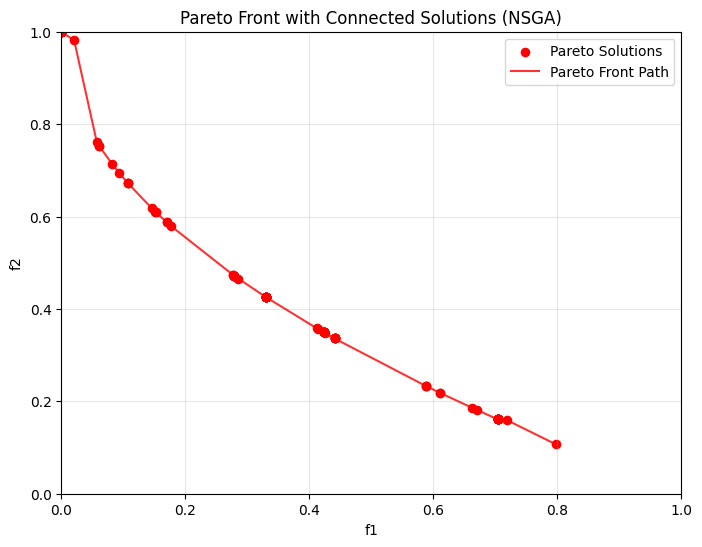

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Sắp xếp theo f1
idx = np.argsort(pareto_F[:, 0])
f1_sorted = pareto_F[idx, 0]
f2_sorted = pareto_F[idx, 1]

plt.figure(figsize=(8, 6))

# Điểm Pareto
plt.scatter(f1_sorted, f2_sorted,
            color='red', s=35, label="Pareto Solutions")

# 🔥 Nối các điểm liên tiếp
plt.plot(f1_sorted, f2_sorted,
         color='red', linewidth=1.5, alpha=0.8, label="Pareto Front Path")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel("f1")
plt.ylabel("f2")
plt.title("Pareto Front with Connected Solutions (NSGA)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()




Giải thích cấu trúc (so sánh với `pymoo`)
| Thành phần trong code        | Ý nghĩa trong thuật toán                            | Tương tự trong `pymoo`                |
| ---------------------------- | --------------------------------------------------- | ------------------------------------- |
| `non_dominated_sort()`       | Phân loại nghiệm theo cấp không bị trội             | `NonDominatedSorting()`               |
| `fitness_sharing()`          | Giữ đa dạng nghiệm (giảm fitness cho điểm gần nhau) | **Crowding Distance** (trong NSGA-II) |
| `select_next_population()`   | Chọn cá thể dựa vào rank và sharing                 | `select_by_rank_and_distance()`       |
| `crossover()` + `mutation()` | Sinh con                                            | `algorithm.mating.do()`               |
| **Không có elitism**         | Giống NSGA gốc — nghiệm tốt có thể mất              | NSGA-II thêm elitism để khắc phục     |


# **NSGA-III**

### **Ví dụ chạy thuật toán NSGA-III trong thư viện `pymoo`, thực hiện tối ưu bài toán `DTLZ1` với 3 mục tiêu.**

###  1. Mục tiêu của bài toán **DTLZ1**

`DTLZ1` là bài toán **kiểm thử (benchmark)** cho các thuật toán **tối ưu đa mục tiêu (MOO)**.  
Mục tiêu là **tối thiểu hóa vector hàm mục tiêu**:

$$
\min f(x) = (f_1(x), f_2(x), \dots, f_M(x))
$$

với ràng buộc đơn giản:

$$
0 \leq x_i \leq 1.
$$


###  2. Cấu trúc biến

Tổng số biến:

$$
n = M + k - 1
$$

Với DTLZ1, ta có:

$$
k = 5
$$

Ví dụ:  
Nếu có **3 mục tiêu (M = 3)** thì:

$$
n = 3 + 5 - 1 = 7.
$$



###  3. Hàm trung gian $ g(x_M, \dots, x_n) $

Hàm \( g(x) \) chịu trách nhiệm điều khiển **độ khó** và **số Pareto front cục bộ**:

$$
g(x_M, \dots, x_n) =
100 \left[
k + \sum_{i=M}^{n} \left( (x_i - 0.5)^2 - \cos(20\pi(x_i - 0.5)) \right)
\right]
$$

Trong đó:

$$
k = n - M + 1, \quad g(x) \ge 0.
$$



###  4. Các hàm mục tiêu $ f_i(x) $

Các hàm mục tiêu được định nghĩa như sau:

$$
\begin{aligned}
f_1(x) &= \frac{1}{2} \, x_1 x_2 \cdots x_{M-1} \, (1 + g(x)) \\
f_2(x) &= \frac{1}{2} \, x_1 x_2 \cdots (1 - x_{M-1}) \, (1 + g(x)) \\
&\vdots \\
f_{M-1}(x) &= \frac{1}{2} \, x_1 (1 - x_2) \, (1 + g(x)) \\
f_M(x) &= \frac{1}{2} \, (1 - x_1) \, (1 + g(x))
\end{aligned}
$$

Công thức tổng quát:

$$
f_i(x) = \frac{1}{2} (1 + g(x))
\prod_{j=1}^{M-i} x_j
\times
\begin{cases}
1, & \text{nếu } i = 1 \\
(1 - x_{M-i+1}), & \text{nếu } i > 1
\end{cases}
$$



###  5. Đặc điểm của **Pareto Front** (nghiệm tối ưu)

Tại nghiệm Pareto tối ưu, ta có:

$$
g(x) = 0 \quad \Rightarrow \quad x_M = x_{M+1} = \dots = x_n = 0.5
$$

Do đó:

$$
f_1 + f_2 + \dots + f_M = 0.5
$$

 Pareto front là một **mặt phẳng (hyperplane) tuyến tính** trong không gian mục tiêu.

Ví dụ với **3 mục tiêu**:

$$
f_1 + f_2 + f_3 = 0.5
$$

 Đây là **một mặt phẳng tam giác đều** trong không gian $(f_1, f_2, f_3)$.

 ### 6. Tính chất của **DTLZ1**
 | Thuộc tính                | Mô tả                                                                |
| ------------------------- | -------------------------------------------------------------------- |
| **Số mục tiêu (M)**       | Tùy chọn (≥2), thường dùng 3–15                                      |
| **Số biến (n)**           | ( M + 4 )                                                            |
| **Miền giá trị của biến** | ( [0, 1] )                                                           |
| **Hàm g(x)**              | Phi tuyến, tạo ra nhiều cực trị cục bộ (local fronts)                |
| **Pareto front**          | Tuyến tính, $ \sum_i f_i = 0.5 $.                                       |
| **Mục tiêu**              | Kiểm tra khả năng hội tụ và phân bố nghiệm đều trên mặt phẳng Pareto |



In [ ]:
# DTLZ1
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.optimize import minimize
from pymoo.problems import get_problem
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.visualization.scatter import Scatter

# create the reference directions to be used for the optimization
ref_dirs = get_reference_directions("das-dennis", 3, n_partitions=12)

# create the algorithm object
algorithm = NSGA3(pop_size=92,
                  ref_dirs=ref_dirs)

# execute the optimization
res = minimize(get_problem("dtlz1"),
               algorithm,
               seed=1,
               termination=('n_gen', 600))

Scatter().add(res.F).show()

### **Ví dụ thêm trên pymoo không được đề cập trong bài báo NSGA-III**

### Thử thay `DTLZ1⁻¹` thay vì `DTLZ1`

### Giải thích rõ sự khác biệt giữa `DTLZ1` và `DTLZ1⁻¹`

### 1. `"DTLZ1"` – Bài toán gốc (Minimization)

**Định nghĩa:**

$$
\min f(x) = (f_1(x), f_2(x), \dots, f_M(x))
$$

với Pareto front:

$$
f_1 + f_2 + f_3 = 0.5
$$

Tức là tất cả các giá trị $ f_i $ được **tối thiểu hóa**,  
và mặt Pareto là **một mặt phẳng gần gốc tọa độ (0, 0, 0)**.

---

### 2. `"DTLZ1⁻¹"` – Phiên bản nghịch đảo (*Inverted problem*)

Khi bạn thêm **“^-1”** vào sau tên bài toán (ví dụ `"DTLZ1⁻¹"`),  
**pymoo** sẽ **tự động chuyển hướng mục tiêu từ “minimize” sang “maximize”** bằng cách nghịch đảo các giá trị hàm mục tiêu:

$$
f_i^{new}(x) = 1 - f_i(x)
$$

Do đó, **Pareto front** bị **lật ngược** so với gốc tọa độ.  
Nếu mặt Pareto của DTLZ1 gốc nằm gần (0, 0, 0), thì  
mặt Pareto của `"DTLZ1⁻¹"` sẽ nằm gần (1, 1, 1).

###3. Ý nghĩa hình học

| Phiên bản  | Phương trình Pareto front (3 mục tiêu)                                  | Hình dạng trong không gian        |
| ---------- | ----------------------------------------------------------------------- | --------------------------------- |
| `DTLZ1`    | $ f_1 + f_2 + f_3 = 0.5 $                                               | Mặt phẳng gần (0,0,0)             |
| `DTLZ1⁻¹` | $ (1 - f_1) + (1 - f_2) + (1 - f_3) = 0.5 ) → ( f_1 + f_2 + f_3 = 2.5) $ | Mặt phẳng “lật ngược” gần (1,1,1) |



In [ ]:
# DTLZ1^-1
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.optimize import minimize
from pymoo.problems import get_problem
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.visualization.scatter import Scatter

ref_dirs = get_reference_directions("das-dennis", 3, n_partitions=12)
algorithm = NSGA3(pop_size=92, ref_dirs=ref_dirs)

res = minimize(get_problem("dtlz1^-1"),   # <-- nghịch đảo Pareto front
               algorithm,
               seed=1,
               termination=('n_gen', 600))

Scatter().add(res.F).show()


###  **Algorithm 1: Generation t of NSGA-III**

**Procedure**

**Input:**  
- $ H $: number of divisions (defines structured reference points)  
- $ Z_s $: structured reference points  
- hoặc $ Z_a $: supplied aspiration points  
- $ P_t $: parent population at generation t  

**Output:**  
- $ P_{t+1} $: next generation population  


1. $ S_t = \varnothing, \; i = 1 $
2. $ Q_t = \text{Recombination + Mutation}(P_t) $  
3. $ R_t = P_t \cup Q_t $  
4. $ (F_1, F_2, \dots) = \text{Non-dominated-sort}(R_t) $
5. **repeat**  
6. &nbsp;&nbsp;&nbsp; $ S_t = S_t \cup F_i $, $ i = i + 1 $  
7. **until** $ |S_t| \ge N $
8. Last front to be included: $ F_\ell = F_i $
9. **if** $ |S_t| = N $ **then**  
10. &nbsp;&nbsp;&nbsp; $ P_{t+1} = S_t $; **break**  
11. **else**  
12. &nbsp;&nbsp;&nbsp; $ P_{t+1} = \bigcup_{j=1}^{\ell-1} F_j $
13. &nbsp;&nbsp;&nbsp; Points to be chosen from $ F_\ell $:  
  $ K = N - |P_{t+1}| $  
14. &nbsp;&nbsp;&nbsp; Normalize objectives and create reference set $ Z_r $:  
  `Normalize( fₙ, Sₜ, Zᵣ, Zₛ, Zₐ )`  
15. &nbsp;&nbsp;&nbsp; Associate each member $ s \in S_t $ with a reference point:  
  $$
  [\pi(s), d(s)] = \text{Associate}(S_t, Z_r)
  $$  
  where  $ \pi(s) $: index of closest reference point,  
    $ d(s) $: distance between s and its reference point  
16. &nbsp;&nbsp;&nbsp; Compute **niche count** for each reference point $ j \in Z_r $:  
  $$
  \rho_j = \sum_{s \in S_t / F_\ell}
  \Big( (\pi(s) = j) ? 1 : 0 \Big)
  $$  
17. &nbsp;&nbsp;&nbsp; Choose K members one at a time from $ F_\ell $ to construct $ P_{t+1} $:  
  `Niching( K, ρⱼ, π, d, Zᵣ, Fₗ, Pₜ₊₁ )`  
18. **end if**


 *Giải thích:*  
Thuật toán này mô tả **vòng lặp tiến hóa chính của NSGA-III**.  
Các bước quan trọng gồm:
- **Phân loại non-dominated** để tạo các front \( F_i \)  
- **Chuẩn hóa & gán reference points** để duy trì đa dạng  
- **Chọn cá thể bằng cơ chế niching** (ưu tiên vùng ít cá thể hơn)


In [ ]:
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.optimize import minimize
from pymoo.problems import get_problem
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.visualization.scatter import Scatter

#1. Tạo reference directions (Z^s)
# Das–Dennis method
ref_dirs = get_reference_directions("das-dennis", 3, n_partitions=12)

#2. Khởi tạo thuật toán NSGA-III
algorithm = NSGA3(
    pop_size=92,          # kích thước quần thể N ≈ số điểm tham chiếu
    ref_dirs=ref_dirs     # truyền tập điểm tham chiếu Z^s
)

#3. Chạy tối ưu cho bài toán DTLZ1
res = minimize(
    problem=get_problem("dtlz1"),  # bài toán kiểm thử DTLZ1
    algorithm=algorithm,
    termination=('n_gen', 600),    # số thế hệ = 600
    seed=1,
    verbose=True
)

#4. Kết quả
print("Các giá trị mục tiêu (F):")
print(res.F)
print("Số nghiệm không trội thu được:", len(res.F))

#5. Hiển thị Pareto Front
Scatter(title="NSGA-III on DTLZ1 (3 objectives)").add(res.F).show()

###  **Algorithm 2: Normalize ( $ f_n, S_t, Z_r, Z_s / Z_a $ )**

**Procedure**

**Input:**  
- $ S_t, Z_s $: structured points  
- hoặc $ Z_a $: supplied (aspiration) points  

**Output:**  
- $ f_n $: normalized objective values  
- $ Z_r $: reference points on normalized hyper-plane  


1. **for** $ j = 1 $ **to** $ M $ **do**  
2. &nbsp;&nbsp;&nbsp;Compute ideal point:  
   $$
   z^{\min}_j = \min_{s \in S_t} f_j(s)
   $$  
3. &nbsp;&nbsp;&nbsp;Translate objectives:  
   $$
   f'_j(s) = f_j(s) - z^{\min}_j, \quad \forall s \in S_t
   $$  
4. &nbsp;&nbsp;&nbsp;Compute extreme points $ (z_{j,\max}), \; j = 1, \dots, M $ of $ S_t $  
5. **end for**  
6. Compute intercepts $ a_j $ for $ j = 1, \dots, M $  
7. Normalize objectives $ f_n $ using *Equation (4)*  
8. **if** $ Z_a $ is given **then**  
9. &nbsp;&nbsp;&nbsp;Map each (aspiration) point on normalized hyper-plane  
   using *Equation (4)* and save in $ Z_r $  
10. **else**  
11. &nbsp;&nbsp;&nbsp;Set $ Z_r = Z_s $  
12. **end if**


 *Mục tiêu:*  
Thuật toán này đảm bảo các giá trị mục tiêu $ f_n $ được **chuẩn hóa về cùng một hyper-plane**, giúp việc so sánh và phân bố reference points trong **NSGA-III** trở nên hiệu quả hơn.


In [ ]:
import numpy as np

# f = các giá trị mục tiêu trong quần thể (M mục tiêu)
f = np.array([
    [0.1, 0.4, 0.5],
    [0.3, 0.2, 0.6],
    [0.2, 0.5, 0.3]
])

# 1. Ideal point
z_min = f.min(axis=0)

# 2. Dịch chuyển
f_shifted = f - z_min

# 3. Ước lượng z_max = giá trị cực trị theo trục
z_max = f.max(axis=0)

# 4. Chuẩn hóa
f_norm = f_shifted / (z_max - z_min)

print("Ideal point:", z_min)
print("Normalized objectives:\n", f_norm)


###  **Algorithm 3: Associate($S_t, Z_r$)**

**Procedure**

**Input:**  
- $Z_r$: set of reference points  
- $S_t$: set of population members  

**Output:**  
- $\pi(s)$: associated reference point for each $s \in S_t$  
- $d(s)$: perpendicular distance from $s$ to its reference line  

---

1. **for each** reference point $z \in Z_r$ **do**  
2. &nbsp;&nbsp;&nbsp; Compute reference line $w = z$  
3. **end for**  
4. **for each** $s \in S_t$ **do**  
5. &nbsp;&nbsp;&nbsp; **for each** $w \in Z_r$ **do**  
6. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Compute perpendicular distance:  

$$
d_{\perp}(s, w) = \left\| s - \frac{w^T s}{\|w\|^2} w \right\|
$$

7. &nbsp;&nbsp;&nbsp; **end for**  
8. &nbsp;&nbsp;&nbsp; Assign  

$$
\pi(s) = \arg \min_{w \in Z_r} d_{\perp}(s, w)
$$  

9. &nbsp;&nbsp;&nbsp; Assign $d(s) = d_{\perp}(s, \pi(s))$  
10. **end for**

---

 *Giải thích:*  
Thuật toán **Associate()** dùng để **gán mỗi cá thể** $s \in S_t$ vào **một điểm tham chiếu** $z \in Z_r$ gần nhất.  
- Khoảng cách $d_{\perp}(s, w)$ đo theo **vuông góc với đường tham chiếu**.  
- Mỗi cá thể chỉ thuộc về **một reference point gần nhất**.  
- Kết quả $\pi(s)$ và $d(s)$ được sử dụng tro



In [ ]:
import numpy as np
from numpy.linalg import norm

# f_norm: điểm mục tiêu chuẩn hóa
f_norm = np.array([[0.2, 0.5, 0.3], [0.4, 0.3, 0.2]])

# Z': reference points chuẩn hóa
Z = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

pi = []   # điểm tham chiếu gần nhất
d = []    # khoảng cách vuông góc

for s in f_norm:
    s_norm = s / norm(s)
    best_j, best_d = None, np.inf
    for j, z in enumerate(Z):
        z_norm = z / norm(z)
        dist = norm(s_norm - np.dot(s_norm, z_norm) * z_norm)
        if dist < best_d:
            best_j, best_d = j, dist
    pi.append(best_j)
    d.append(best_d)

print("π(s):", pi)
print("d(s):", d)


###  **Algorithm 4: Niching($K, \rho_j, \pi, d, Z_r, F_l, P_{t+1}$)**

**Procedure**

**Input:**  
- $K$: số lượng cá thể cần chọn thêm  
- $\rho_j$: số lượng cá thể đã gán cho điểm tham chiếu $j$  
- $\pi(s)$: điểm tham chiếu gần nhất của cá thể $s$  
- $d(s)$: khoảng cách vuông góc từ $s$ đến $\pi(s)$  
- $Z_r$: tập các điểm tham chiếu  
- $F_l$: front cuối cùng  
- $P_{t+1}$: quần thể thế hệ tiếp theo  

**Output:**  
- $P_{t+1}$ được hoàn thiện (đủ $N$ cá thể)


1. $k = 1$  
2. **while** $k \le K$ **do**  
3. &nbsp;&nbsp;&nbsp; $J_{\min} = \{ j : \arg\min_{j \in Z_r} \rho_j \}$  
4. &nbsp;&nbsp;&nbsp; Chọn ngẫu nhiên $ \bar{j} \in J_{\min} $  
5. &nbsp;&nbsp;&nbsp; $I_{\bar{j}} = \{ s : \pi(s) = \bar{j}, s \in F_l \}$  
6. &nbsp;&nbsp;&nbsp; **if** $I_{\bar{j}} \ne \emptyset$ **then**  
7. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; **if** $\rho_{\bar{j}} = 0$ **then**  
8. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $P_{t+1} = P_{t+1} \cup \{ s : \arg\min_{s \in I_{\bar{j}}} d(s) \}$  
9. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; **else**  
10. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $P_{t+1} = P_{t+1} \cup \text{random}(I_{\bar{j}})$  
11. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; **end if**  
12. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\rho_{\bar{j}} = \rho_{\bar{j}} + 1$, $F_l = F_l \setminus s$  
13. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $k = k + 1$  
14. &nbsp;&nbsp;&nbsp; **else**  
15. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $Z_r = Z_r \setminus \{ \bar{j} \}$  
16. &nbsp;&nbsp;&nbsp; **end if**  
17. **end while**


 *Giải thích:*  
- Thuật toán **Niching()** chịu trách nhiệm **chọn thêm $K$ cá thể** từ front cuối ($F_l$) để hoàn thành quần thể $P_{t+1}$.  
- Ưu tiên các điểm tham chiếu có **mật độ nhỏ nhất** ($\rho_j$ thấp).  
- Nếu một điểm tham chiếu **chưa có cá thể nào** ($\rho_j = 0$), chọn **cá thể gần nhất** với điểm đó.  
- Nếu đã có, chọn **ngẫu nhiên một cá thể** khác cùng nhóm để tăng đa dạng.  


In [ ]:
import numpy as np

# Giả sử ta cần chọn 3 cá thể (K = 3)
K = 3
rho = np.array([1, 0, 2])      # số cá thể hiện tại ở mỗi điểm ref
pi = np.array([0, 1, 2, 1])    # cá thể → ref point
d = np.array([0.3, 0.1, 0.2, 0.4])  # khoảng cách cá thể đến ref point

selected = []

while len(selected) < K:
    # 1. Chọn điểm ref có ρ nhỏ nhất
    j_min = np.argmin(rho)

    # 2. Lọc các cá thể liên kết với j_min
    candidates = np.where(pi == j_min)[0]
    if len(candidates) == 0:
        rho[j_min] = np.inf
        continue

    # 3. Chọn cá thể có khoảng cách nhỏ nhất
    chosen = candidates[np.argmin(d[candidates])]

    # 4. Cập nhật
    selected.append(chosen)
    rho[j_min] += 1

print("Các cá thể được chọn:", selected)


### **Tóm tắt luồng thuật toán NSGA-III**
- **Bước 1:** Khởi tạo quần thể ban đầu $ P_0 $

- **Bước 2:** Tạo các điểm tham chiếu đều nhau (reference points)

- **Lặp lại cho đến khi điều kiện dừng thỏa mãn:**

    1. Sinh quần thể con $ Q_t $ từ $ P_t $ bằng lai ghép và đột biến
    2. Gộp quần thể: $ R_t = P_t \cup Q_t $
    3. Phân loại quần thể theo độ không trội (thu được các front $ F_1, F_2, … $)
    4. Chọn các front liên tiếp để đạt đến $ N $ cá thể
    5. Nếu vượt quá $ N $ → áp dụng **reference-based niching** để chọn cá thể
    6. Tạo thế hệ mới: $ P_{t+1} = $ tập cá thể được chọn

- **Bước 3:** Kết thúc thuật toán, xuất tập nghiệm không trội cuối cùng.


# **R-NSGA-III**

**Thuật toán R-NSGA-III (Reference-point NSGA-III) giải bài toán `ZDT1`**

In [ ]:
import numpy as np

from pymoo.algorithms.moo.rnsga3 import RNSGA3
from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

problem = get_problem("zdt1")
pf = problem.pareto_front()

# Define reference points
ref_points = np.array([[0.3, 0.4], [0.8, 0.5]])

# Get Algorithm
algorithm = RNSGA3(
    ref_points=ref_points,
    pop_per_ref_point=50,
    mu=0.1)

res = minimize(problem,
               algorithm=algorithm,
               termination=('n_gen', 300),
               pf=pf,
               seed=1,
               verbose=False)

reference_directions = res.algorithm.survival.ref_dirs

plot = Scatter()
plot.add(pf, label="pf")
plot.add(res.F, label="F")
plot.add(ref_points, label="ref_points")
plot.add(reference_directions, label="ref_dirs")
plot.show()

**Thuật toán R-NSGA-III (Reference-point NSGA-III) giải bài toán `DTLZ4`**

##  Tổng quan: Bài toán DTLZ4

Bài toán **DTLZ4** (Deb, Thiele, Laumanns, Zitzler) là một trong các **bài toán chuẩn** dùng để kiểm tra hiệu quả của các **thuật toán tối ưu hóa đa mục tiêu (Multi-objective Optimization)**.

- **Số hàm mục tiêu:** `n_obj = 3`  
- **Số biến quyết định:** `n_var = 12`

---

### 🔹 Công thức tổng quát của DTLZ4

$$
\begin{cases}
f_1(\mathbf{x}) = (1 + g(\mathbf{x})) \cos^{\alpha}\left(\frac{\pi}{2}x_1\right) \cos^{\alpha}\left(\frac{\pi}{2}x_2\right) \\
f_2(\mathbf{x}) = (1 + g(\mathbf{x})) \cos^{\alpha}\left(\frac{\pi}{2}x_1\right) \sin^{\alpha}\left(\frac{\pi}{2}x_2\right) \\
f_3(\mathbf{x}) = (1 + g(\mathbf{x})) \sin^{\alpha}\left(\frac{\pi}{2}x_1\right)
\end{cases}
$$

trong đó:

$$
g(\mathbf{x}) = \sum_{i=3}^{12} (x_i - 0.5)^2, \quad x_i \in [0,1]
$$

và:

$$
\alpha = 100
$$

---

### 💡 Giải thích

- Tham số **$\alpha$** điều khiển **độ cong của mặt Pareto**.  
  Khi $\alpha$ càng lớn → mặt Pareto càng bị **cong lệch**, gây khó khăn hơn trong việc tìm nghiệm tối ưu.  
- Hàm $g(\mathbf{x})$ mô tả **mức độ phức tạp** trong các biến phụ.  
- DTLZ4 có cấu trúc tương tự DTLZ2, **nhưng khó hơn** do biến đổi lũy thừa $\alpha$ làm **mất cân bằng phân bố nghiệm**.

---

### 📊 Bảng tóm tắt

| Thuộc tính | Giá trị |
|-------------|----------|
| Số biến | 12 |
| Số hàm mục tiêu | 3 |
| Miền xác định | $x_i \in [0,1]$ |
| Hàm $g(\mathbf{x})$ | $\displaystyle \sum_{i=3}^{12}(x_i - 0.5)^2$ |
| Tham số $\alpha$ | 100 |
| Độ khó | Cao hơn DTLZ2 |
| Pareto front | Cong và lệch mạnh |

---

### 🎯 Ý nghĩa

DTLZ4 thường được sử dụng để **đánh giá khả năng bao phủ Pareto front** của các thuật toán như **NSGA-II**, **NSGA-III**, **MOEA/D**,…  
Đặc biệt thích hợp để kiểm tra xem thuật toán có bị “thiên lệch” về một vùng nhất định trên mặt Pareto hay không.


In [ ]:
from pymoo.util.reference_direction import UniformReferenceDirectionFactory

# Get problem
problem = get_problem("dtlz4", n_var=12, n_obj=3)

# Define reference points and reference directions
ref_points = np.array([[1.0, 0.5, 0.2], [0.3, 0.2, 0.6]])
ref_dirs = UniformReferenceDirectionFactory(3, n_points=91).do()
pf = problem.pareto_front(ref_dirs)

# Get Algorithm
algorithm = RNSGA3(
    ref_points=ref_points,
    pop_per_ref_point=91,
    mu=0.1)

res = minimize(problem,
               algorithm,
               termination=('n_gen', 300),
               pf=pf,
               seed=1,
               verbose=False)


plot = Scatter()
plot.add(pf, label="pf")
plot.add(res.F, label="F")
plot.add(ref_points, label="ref_points")
plot.show()

**R-NSGA-II**

In [ ]:
#Mã giả
Input:
  - pop_parent: parent population (size N)
  - offspring: offspring population (size N)
  - aspiration_points = {r^(1), r^(2), ..., r^(K)}
  - epsilon: clearing radius in objective space
  - N: population size to keep
Output:
  - next_generation: population of size N

Procedure R-NSGA-II_Select(pop_parent, offspring, aspiration_points, epsilon, N):
1. R <- pop_parent ∪ offspring      # merged population (size 2N)
2. Evaluate objective vectors for all members in R
3. Fronts = FastNonDominatedSort(R) # F1, F2, ..., Fm
4. Initialize:
     rank_map = {}                  # mapping individual -> assigned rank (lower is better)
     cleared_per_front = []         # cleared members for each front (store lists)
     next_rank = 1
5. For each front Fi in Fronts (i = 1..m):
     candidates = list(indices of members in Fi)
     assigned_in_front = []
     cleared_in_front = []
     # Clearing rounds within this front
     while candidates not empty:
         # One round: for each aspiration point find closest candidate
         for r in aspiration_points:
             if candidates empty: break
             idx = argmin_{c in candidates} distance(normalize(obj[c]), r)
             # assign rank to idx
             rank_map[idx] = next_rank
             assigned_in_front.append(idx)
             # remove idx from candidates
             candidates.remove(idx)
             # clear (temporarily remove) any candidate within epsilon of idx
             for c in list(candidates):
                 if distance(normalize(obj[c]), normalize(obj[idx])) <= epsilon:
                     candidates.remove(c)
                     cleared_in_front.append(c)
         next_rank += 1
     push cleared_in_front into cleared_per_front

6. # After processing all fronts once, assign ranks to cleared members
   # Process cleared members in front order, repeating the clearing-round procedure
   for each cleared_list in cleared_per_front:
       candidates = cleared_list (those not yet ranked)
       while candidates not empty:
           for r in aspiration_points:
               if candidates empty: break
               idx = argmin_{c in candidates} distance(normalize(obj[c]), r)
               rank_map[idx] = next_rank
               candidates.remove(idx)
               for c in list(candidates):
                   if distance(normalize(obj[c]), normalize(obj[idx])) <= epsilon:
                       candidates.remove(c)
                       # append to a temporary list to be processed later (if any)
                       add c to next_cleared_list
           next_rank += 1
       # if next_cleared_list not empty, append it for subsequent rounds (repeat until all assigned)

7. # Now all individuals in R have rank_map values.
8. # Selection: binary tournament with rank as primary criterion
   # (tie-break arbitrarily or by crowding distance if you want)
   next_generation = []
   while len(next_generation) < N:
       a, b = two random distinct indices from R
       if rank_map[a] < rank_map[b]: winner = a
       elif rank_map[b] < rank_map[a]: winner = b
       else: winner = random choice between a and b
       add winner to next_generation (if not already selected)
9. return next_generation


**Thư viện pymoo hiện tại KHÔNG cung cấp sẵn thuật toán R-NSGA-II nên dùng Python tự cài đặt**

In [ ]:
# r_nsga2_demo.py
import numpy as np
import random
import math
import matplotlib.pyplot as plt

# ---------- Problem: ZDT1 ----------
def zdt1_eval(x):
    # x: vector of length n
    f1 = x[0]
    n = len(x)
    g = 1 + 9.0 * sum(x[1:]) / (n - 1)
    f2 = g * (1 - math.sqrt(f1 / g))
    return np.array([f1, f2])

# ---------- Helpers: nondominated sort ----------
def fast_non_dominated_sort(pop_objs):
    N = len(pop_objs)
    S = [[] for _ in range(N)]
    n = [0]*N
    rank = [None]*N
    fronts = [[]]
    for p in range(N):
        S[p] = []
        n[p] = 0
        for q in range(N):
            # Use np.all and np.any for element-wise comparison of arrays
            if np.all(pop_objs[p] <= pop_objs[q]) and np.any(pop_objs[p] < pop_objs[q]):
                S[p].append(q)
            elif np.all(pop_objs[q] <= pop_objs[p]) and np.any(pop_objs[q] < pop_objs[p]):
                n[p] += 1
        if n[p] == 0:
            rank[p] = 0
            fronts[0].append(p)
    i = 0
    while fronts[i]:
        Q = []
        for p in fronts[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0:
                    rank[q] = i+1
                    Q.append(q)
        i += 1
        fronts.append(Q)
    fronts.pop()  # last empty
    return fronts

# ---------- Normalize objectives (min-max across population) ----------
def normalize_objs(pop_objs):
    arr = np.array(pop_objs)
    fmin = arr.min(axis=0)
    fmax = arr.max(axis=0)
    denom = (fmax - fmin)
    denom[denom==0] = 1.0
    norm = (arr - fmin)/denom
    return norm

# ---------- Clearing-based ranking (R-NSGA-II core) ----------
def r_nsga2_clearing_ranking(pop_objs, fronts, aspiration_points, eps):
    Npop = len(pop_objs)
    rank = np.full(Npop, np.inf) # Use a numpy array for ranks, initialized to infinity
    # normalize entire population once for distance calc
    norm_all = normalize_objs(pop_objs)

    next_rank = 0 # Start ranks from 0
    remaining_indices = list(range(Npop)) # Indices of individuals not yet ranked

    current_candidates = []
    for front in fronts:
        current_candidates.extend(front) # Add individuals from each front to candidates

    while remaining_indices:
        cleared_round = []
        assigned_this_round = []
        candidates_this_round = [idx for idx in current_candidates if idx in remaining_indices]

        if not candidates_this_round: # If no remaining candidates, break
            break

        # one round: for each aspiration point choose closest candidate
        for r in aspiration_points:
            valid_candidates = [idx for idx in candidates_this_round if idx in remaining_indices]
            if not valid_candidates:
                break

            # compute distances to normalized aspiration r
            dlist = [np.linalg.norm(norm_all[c] - r) for c in valid_candidates]
            idx_local = np.argmin(dlist)
            chosen_idx = valid_candidates[idx_local]

            # Assign rank and remove from remaining
            rank[chosen_idx] = next_rank
            remaining_indices.remove(chosen_idx)
            assigned_this_round.append(chosen_idx)

            # clear neighbors within eps (distance in normalized obj space)
            neighbors_to_clear = []
            for c in candidates_this_round:
                if c in remaining_indices and np.linalg.norm(norm_all[c] - norm_all[chosen_idx]) <= eps:
                    neighbors_to_clear.append(c)

            for neighbor_idx in neighbors_to_clear:
                 if neighbor_idx in remaining_indices:
                    remaining_indices.remove(neighbor_idx)
                    cleared_round.append(neighbor_idx)


        next_rank += 1
        # Individuals not assigned or cleared in this round become candidates for the next round
        current_candidates = cleared_round # Cleared individuals become candidates for the next clearing round


    return rank


# ---------- Variation operators (SBX + Polynomial Mutation) ----------
def sbx_crossover(p1, p2, eta=15, prob=0.9):
    n = len(p1)
    if random.random() > prob:
        return p1.copy(), p2.copy()
    child1 = np.zeros(n)
    child2 = np.zeros(n)
    for i in range(n):
        u = random.random()
        if u <= 0.5:
            beta = (2*u)**(1/(eta+1))
        else:
            beta = (1/(2*(1-u)))**(1/(eta+1))
        child1[i] = 0.5*((1+beta)*p1[i] + (1-beta)*p2[i])
        child2[i] = 0.5*((1-beta)*p1[i] + (1+beta)*p2[i])
        # repair to [0,1]
        child1[i] = min(max(child1[i], 0.0), 1.0)
        child2[i] = min(max(child2[i], 0.0), 1.0)
    return child1, child2

def poly_mutation(x, eta=20, prob=None):
    n = len(x)
    if prob is None:
        prob = 1.0/n
    y = x.copy()
    for i in range(n):
        if random.random() < prob:
            u = random.random()
            if u < 0.5:
                delta = (2*u)**(1/(eta+1)) - 1
            else:
                delta = 1 - (2*(1-u))**(1/(eta+1))
            y[i] = y[i] + delta
            y[i] = min(max(y[i], 0.0), 1.0)
    return y

# ---------- Main R-NSGA-II GA ----------
def r_nsga2_run(n_var=30, pop_size=100, gens=100, aspiration_points=None, eps=0.02):
    # initialize
    pop = [np.random.rand(n_var) for _ in range(pop_size)]
    pop_objs = [zdt1_eval(ind) for ind in pop]

    for gen in range(gens):
        # create offspring via binary tournament on ranks or random if first gen
        # Simple reproduction: random pairings + SBX + mutation
        off = []
        while len(off) < pop_size:
            p1, p2 = random.sample(pop, 2)
            c1, c2 = sbx_crossover(p1, p2)
            c1 = poly_mutation(c1)
            c2 = poly_mutation(c2)
            off.append(c1)
            if len(off) < pop_size:
                off.append(c2)
        off_objs = [zdt1_eval(ind) for ind in off]

        # Merge
        merged = pop + off
        merged_objs = pop_objs + off_objs

        # Non-dominated sort
        fronts = fast_non_dominated_sort(merged_objs)

        # R-NSGA-II clearing ranking
        # normalize aspiration points by using min-max of merged pop
        merged_arr = np.array(merged_objs)
        fmin = merged_arr.min(axis=0)
        fmax = merged_arr.max(axis=0)
        denom = (fmax - fmin)
        denom[denom==0] = 1.0
        # prepare normalized aspiration points (same normalization space)
        asp_norm = []
        for r in aspiration_points:
            asp_norm.append((np.array(r) - fmin)/denom)
        asp_norm = [np.array(a) for a in asp_norm]

        ranks = r_nsga2_clearing_ranking(merged_objs, fronts, asp_norm, eps)

        # binary tournament selection based on ranks -> new pop
        new_pop = []
        new_pop_set = set() # Use a set to track individuals for uniqueness
        new_pop_objs = []
        merged_with_ranks = [(merged[i], merged_objs[i], ranks[i]) for i in range(len(merged))]

        # Sort merged_with_ranks based on ranks (ascending)
        merged_with_ranks.sort(key=lambda x: x[2])


        while len(new_pop) < pop_size:
            # Take the best individuals based on rank until pop_size is reached
            # This replaces the binary tournament selection with a simpler truncation selection based on the R-NSGA-II rank
            for ind, obj, rank_val in merged_with_ranks:
                if len(new_pop) >= pop_size:
                    break
                winner_tuple = tuple(ind)
                if winner_tuple not in new_pop_set:
                    new_pop_set.add(winner_tuple)
                    new_pop.append(ind)
                    new_pop_objs.append(obj)


        pop = new_pop
        pop_objs = new_pop_objs

        if (gen+1) % 10 == 0:
            print(f"Gen {gen+1} done.")

    return pop, pop_objs

# ---------- Run demo ----------
if __name__ == "__main__":
    random.seed(1)
    np.random.seed(1)

    # aspiration points in objective space (f1, f2) for ZDT1
    # For ZDT1 f1 in [0,1], f2 in [0,1], choose two points
    aspiration_points = [np.array([0.2, 0.8]), np.array([0.7, 0.5])]
    pop, pop_objs = r_nsga2_run(n_var=30, pop_size=100, gens=100,
                                aspiration_points=aspiration_points, eps=0.02)

    arr = np.array(pop_objs)
    plt.scatter(arr[:,0], arr[:,1], s=10, label="R-NSGA-II result")
    # plot pareto front f2 = 1 - sqrt(f1)
    x = np.linspace(0,1,200)
    y = 1 - np.sqrt(x)
    plt.plot(x,y, 'k--', label="True PF")
    aps = np.array(aspiration_points)
    plt.scatter(aps[:,0], aps[:,1], c='red', label="aspiration points", marker='x')
    plt.xlabel("f1"); plt.ylabel("f2")
    plt.legend()
    plt.title("R-NSGA-II demo on ZDT1")
    plt.gca().invert_yaxis()  # visually similar to PF orientation (optional)
    plt.show()

**BR-NSGA-II**

In [ ]:
# Mã giả

Input:
  - population P of size N
  - aspiration points {z(1), z(2), ..., z(K)}
  - ε : clearing radius
Output:
  - new population P_next

1. Combine parent and offspring populations
2. Perform fast non-dominated sorting → fronts F1, F2, ..., Fm
3. Initialize P_next = ∅
   For each aspiration point k: n_k = 0

4. For each front Fi:
      if |P_next| + |Fi| ≤ N:
          Add all Fi members to P_next
          Update counts n_k (associate each solution in Fi to nearest z(k))
      else:
          # Front Fi is the last front (partial selection)
          m = N - |P_next|        # how many more individuals to pick
          total_assigned = sum(n_k)
          total_remaining = N - total_assigned

          For each aspiration point k:
              target_share = total_remaining / K
              m_k = target_share - n_k     # balance adjustment
              if m_k < 0: m_k = 0
              m_k = round(m_k)

          # Now select m_k solutions near each z(k), separated by ε
          For each aspiration point z(k):
              Select m_k closest members in Fi to z(k),
              ensuring pairwise distances ≥ ε.

          Add selected individuals to P_next
          break  # stop (population full)

5. return P_next


**Thư viện pymoo hiện tại KHÔNG cung cấp sẵn thuật toán BR-NSGA-II nên dùng Python tự cài đặt**

In [ ]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt


# ==========================================================
# 1️⃣ Bài toán ví dụ: ZDT1 (2 mục tiêu)
# ==========================================================
def zdt1(x):
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (len(x) - 1)
    f2 = g * (1 - math.sqrt(f1 / g))
    return np.array([f1, f2])


# ==========================================================
# 2️⃣ Công cụ hỗ trợ: Non-dominated sorting
# ==========================================================
def fast_non_dominated_sort(objs):
    N = len(objs)
    S = [[] for _ in range(N)]
    n = [0] * N
    rank = [None] * N
    fronts = [[]]
    for p in range(N):
        for q in range(N):
            if all(objs[p] <= objs[q]) and any(objs[p] < objs[q]):
                S[p].append(q)
            elif all(objs[q] <= objs[p]) and any(objs[q] < objs[p]):
                n[p] += 1
        if n[p] == 0:
            rank[p] = 0
            fronts[0].append(p)
    i = 0
    while fronts[i]:
        Q = []
        for p in fronts[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0:
                    rank[q] = i + 1
                    Q.append(q)
        i += 1
        fronts.append(Q)
    fronts.pop()
    return fronts


# ==========================================================
# 3️⃣ Chuẩn hoá mục tiêu
# ==========================================================
def normalize_objs(F):
    arr = np.array(F)
    fmin = arr.min(axis=0)
    fmax = arr.max(axis=0)
    denom = np.where(fmax - fmin == 0, 1, fmax - fmin)
    return (arr - fmin) / denom


# ==========================================================
# 4️⃣ Crossover và Mutation
# ==========================================================
def sbx_crossover(p1, p2, eta=15, prob=0.9):
    n = len(p1)
    if random.random() > prob:
        return p1.copy(), p2.copy()
    c1, c2 = np.zeros(n), np.zeros(n)
    for i in range(n):
        u = random.random()
        beta = (2 * u) ** (1 / (eta + 1)) if u <= 0.5 else (1 / (2 * (1 - u))) ** (1 / (eta + 1))
        c1[i] = 0.5 * ((1 + beta) * p1[i] + (1 - beta) * p2[i])
        c2[i] = 0.5 * ((1 - beta) * p1[i] + (1 + beta) * p2[i])
        c1[i] = min(max(c1[i], 0), 1)
        c2[i] = min(max(c2[i], 0), 1)
    return c1, c2


def polynomial_mutation(x, eta=20, prob=None):
    n = len(x)
    if prob is None:
        prob = 1 / n
    y = x.copy()
    for i in range(n):
        if random.random() < prob:
            u = random.random()
            delta = (2 * u) ** (1 / (eta + 1)) - 1 if u < 0.5 else 1 - (2 * (1 - u)) ** (1 / (eta + 1))
            y[i] = y[i] + delta
            y[i] = min(max(y[i], 0), 1)
    return y


# ==========================================================
# 5️⃣ BR-NSGA-II Core
# ==========================================================
def br_nsga2(problem_eval, n_var, pop_size, gens, ref_points, eps=0.02):
    pop = [np.random.rand(n_var) for _ in range(pop_size)]
    objs = [problem_eval(x) for x in pop]

    for gen in range(gens):
        # Tạo offspring bằng SBX + Mutation
        offspring = []
        while len(offspring) < pop_size:
            p1, p2 = random.sample(pop, 2)
            c1, c2 = sbx_crossover(p1, p2)
            c1 = polynomial_mutation(c1)
            c2 = polynomial_mutation(c2)
            offspring.append(c1)
            if len(offspring) < pop_size:
                offspring.append(c2)
        offspring_objs = [problem_eval(x) for x in offspring]

        # Hợp nhất
        merged = pop + offspring
        merged_objs = objs + offspring_objs

        # Non-dominated sort
        fronts = fast_non_dominated_sort(merged_objs)
        F_norm = normalize_objs(merged_objs)

        new_pop, new_objs = [], []
        n_k = np.zeros(len(ref_points), dtype=int)

        for front in fronts:
            if len(new_pop) + len(front) <= pop_size:
                for i in front:
                    new_pop.append(merged[i])
                    new_objs.append(merged_objs[i])
                    d = np.linalg.norm(F_norm[i] - ref_points, axis=1)
                    nearest = np.argmin(d)
                    n_k[nearest] += 1
            else:
                m = pop_size - len(new_pop)
                last_front = list(front)

                # Xác định số cá thể cần chọn quanh từng ref_point
                total = n_k.sum()
                K = len(ref_points)
                if total == 0:
                    m_k = np.full(K, m // K)
                else:
                    avg = total / K
                    diff = np.clip(avg - n_k, 0, None)
                    if diff.sum() == 0:
                        m_k = np.full(K, m // K)
                    else:
                        m_k = np.round(m * diff / diff.sum()).astype(int)

                chosen_idx = []
                for k in range(K):
                    if m_k[k] <= 0:
                        continue
                    d = np.linalg.norm(F_norm[last_front] - ref_points[k], axis=1)
                    sorted_idx = np.argsort(d)
                    sel = []
                    for idx in sorted_idx:
                        i = last_front[idx]
                        if all(np.linalg.norm(F_norm[i] - F_norm[j]) > eps for j in sel):
                            sel.append(i)
                            if len(sel) >= m_k[k]:
                                break
                    chosen_idx.extend(sel)

                for i in chosen_idx:
                    new_pop.append(merged[i])
                    new_objs.append(merged_objs[i])
                break  # đủ dân số

        pop, objs = new_pop, new_objs
        if (gen + 1) % 10 == 0:
            print(f"Generation {gen+1}/{gens} completed")

    return np.array(objs)


# ==========================================================
# 6️⃣ Thực thi ví dụ
# ==========================================================
if __name__ == "__main__":
    np.random.seed(1)
    random.seed(1)

    ref_points = np.array([[0.2, 0.8],
                           [0.7, 0.4]])

    results = br_nsga2(problem_eval=zdt1,
                       n_var=30,
                       pop_size=100,
                       gens=100,
                       ref_points=ref_points,
                       eps=0.02)

    # Vẽ kết quả
    plt.figure(figsize=(6, 5))
    plt.scatter(results[:, 0], results[:, 1], s=15, label="BR-NSGA-II results")
    plt.plot(np.linspace(0, 1, 200), 1 - np.sqrt(np.linspace(0, 1, 200)), 'k--', label="True PF")
    plt.scatter(ref_points[:, 0], ref_points[:, 1], c='red', marker='x', label="Ref points")
    plt.xlabel("f1")
    plt.ylabel("f2")
    plt.title("Balanced R-NSGA-II on ZDT1")
    plt.legend()
    plt.show()


**R-NSGA-III**

In [ ]:
# Mã giả
Input: problem, K aspiration points {r^(k)}, shrink μ, Das-Dennis granularity p, pop_size N, gens G
Initialize population P of size N

For generation = 1..G:
  Evaluate F for all members
  Compute f_min, f_max for each objective
  For each aspiration point r^(k):
    rbar = (r^(k) - f_min) / (f_max - f_min)         # normalize
    rdot = rbar / sum(rbar)                         # project to simplex
    H = all Das-Dennis points h^(j) for (M, p)
    hbar^(j) = μ * h^(j)
    g = centroid of {hbar}
    for j: z_jk = hbar^(j) + (rdot - g)
  Za = all z_jk for all k  appended with M identity extremes
  # NSGA-III selection using Za:
  R = parent ∪ offspring
  fronts = nondominated_sort(R)
  Fill next_pop with whole fronts until last_front partial
  For members in last_front:
    Normalize objectives using current f_min,f_max
    For each individual compute perpendicular distance to each Za direction
    Associate individual to nearest Za
  Perform niching: while next_pop size < N:
    find Za with minimal count of associated members (ties broken arbitrarily)
    from that Za's associated set, pick the member with smallest perpendicular distance
    add to next_pop and mark chosen removed
End For
Output: final population
